# Caso 1: SIMPLE - Calidad de Datos de Ingresos Municipalidades (SIAF)

---

## Contexto del Proyecto

### Descripción del Problema
El **Ministerio de Economía y Finanzas (MEF)**, a través del Sistema Integrado de
Administración Financiera (SIAF), registra el presupuesto y ejecución de ingresos
de todos los niveles de gobierno. Al consolidar los datos históricos 2012-2026,
se detectaron inconsistencias en montos, registros de niveles de gobierno no
municipales mezclados, y valores faltantes en columnas clave que impiden
generar reportes presupuestales confiables.

### Objetivo Analítico
Limpiar y mejorar la calidad de los datos de ingresos históricos del SIAF para:
- Filtrar correctamente solo Gobiernos Locales (NIVEL_GOBIERNO = 'M')
- Corregir tipos de dato y tratar valores nulos en montos presupuestales
- Eliminar registros duplicados que distorsionen el análisis
- Construir el UBIGEO necesario para el JOIN con SISMEPRE y RENAMU
- Preparar el archivo Silver listo para el modelo estrella en Gold

### Impacto de la Mala Calidad de Datos
- **Financiero**: Montos de PIA, PIM o MONTO_RECAUDADO incorrectos llevan
a calcular mal el porcentaje de ejecución presupuestal por municipalidad
- **Operativo**: Registros de gobiernos nacionales o regionales mezclados
distorsionan los rankings y comparativos entre municipalidades
- **Estratégico**: Decisiones de política pública basadas en datos incompletos
pueden derivar en asignaciones presupuestales inequitativas entre municipios

---

## Dimensiones de Calidad a Corregir

En este caso aplicaremos correcciones sobre:

1. **Completitud**: Tratar valores nulos en columnas de montos presupuestales
2. **Exactitud**: Corregir tipos de dato incorrectos en MONTO_PIA, MONTO_PIM
y MONTO_RECAUDADO
3. **Consistencia**: Verificar que NIVEL_GOBIERNO y su nombre sean coherentes
4. **Integridad**: Construir UBIGEO de 6 dígitos para garantizar las
relaciones entre SIAF, SISMEPRE y RENAMU
5. **Razonabilidad**: Identificar y documentar montos fuera de rango
6. **Oportunidad**: Verificar cobertura completa del rango 2012-2026
7. **Unicidad**: Eliminar registros duplicados exactos
8. **Validez**: Verificar que los códigos de RUBRO y FUENTE_FINANCIAMIENTO
sean válidos según el catálogo del MEF

---

In [1]:
# Instalación de librerías necesarias
# !pip install pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print("✅ Librerías cargadas correctamente")


✅ Librerías cargadas correctamente


## Carga de Data


In [2]:
df = pd.read_csv('INGRESOS_HISTORICO_TOTAL_2012_2026.csv', encoding='latin-1')

In [3]:
# Vista previa del dataset
df.head(10)

,ANO_DOC,MES_DOC,NIVEL_GOBIERNO,NIVEL_GOBIERNO_NOMBRE,SECTOR,SECTOR_NOMBRE,PLIEGO,PLIEGO_NOMBRE,SEC_EJEC,EJECUTORA,...,SUBGENERICA_DET,SUBGENERICA_DET_NOMBRE,ESPECIFICA,ESPECIFICA_NOMBRE,ESPECIFICA_DET,ESPECIFICA_DET_NOMBRE,MONTO_PIA,MONTO_PIM,MONTO_RECAUDADO,ARCHIVO_ORIGEN
0,2012,1,R,GOBIERNOS REGIONALES,99,GOBIERNOS REGIONALES,440,GOBIERNO REGIONAL AMAZONAS,721,1,...,4,VENTA DE PRODUCTOS INDUSTRIALES,1,VENTA DE PRODUCTOS INDUSTRIALES,3,VENTA DE PRODUCTOS HIDROBIOLOGICOS,44789,44789,577.00,2012-Ingreso.csv
1,2012,1,R,GOBIERNOS REGIONALES,99,GOBIERNOS REGIONALES,440,GOBIERNO REGIONAL AMAZONAS,721,1,...,4,VENTA DE PRODUCTOS INDUSTRIALES,1,VENTA DE PRODUCTOS INDUSTRIALES,4,PRODUCTOS TEXTILES,0,0,0.00,2012-Ingreso.csv
2,2012,1,R,GOBIERNOS REGIONALES,99,GOBIERNOS REGIONALES,440,GOBIERNO REGIONAL AMAZONAS,721,1,...,9,VENTA DE OTROS BIENES,1,VENTA DE OTROS BIENES,2,"VENTA DE BASES PARA LICITACION PUBLICA, CONCUR...",17500,17500,1230.00,2012-Ingreso.csv
3,2012,1,R,GOBIERNOS REGIONALES,99,GOBIERNOS REGIONALES,440,GOBIERNO REGIONAL AMAZONAS,721,1,...,1,DERECHOS ADMINISTRATIVOS GENERALES,1,REGISTROS Y LICENCIAS,1,REGISTRO CIVIL,0,0,0.00,2012-Ingreso.csv
4,2012,1,R,GOBIERNOS REGIONALES,99,GOBIERNOS REGIONALES,440,GOBIERNO REGIONAL AMAZONAS,721,1,...,1,DERECHOS ADMINISTRATIVOS GENERALES,1,REGISTROS Y LICENCIAS,99,OTROS REGISTROS,31706,31706,5515.96,2012-Ingreso.csv
5,2012,1,R,GOBIERNOS REGIONALES,99,GOBIERNOS REGIONALES,440,GOBIERNO REGIONAL AMAZONAS,721,1,...,3,DERECHOS ADMINISTRATIVOS DE EDUCACION,1,DERECHOS ADMINISTRATIVOS DE EDUCACION,4,CONSTANCIAS Y CERTIFICADOS,28600,28600,0.00,2012-Ingreso.csv
6,2012,1,R,GOBIERNOS REGIONALES,99,GOBIERNOS REGIONALES,440,GOBIERNO REGIONAL AMAZONAS,721,1,...,7,DERECHOS ADMINISTRATIVOS DE ENERGIA Y MINAS,1,DERECHOS ADMINISTRATIVOS DE MINERIA,1,DERECHO DE APROBACION Y AUTORIZACION,0,0,1253.00,2012-Ingreso.csv
7,2012,1,R,GOBIERNOS REGIONALES,99,GOBIERNOS REGIONALES,440,GOBIERNO REGIONAL AMAZONAS,721,1,...,7,DERECHOS ADMINISTRATIVOS DE ENERGIA Y MINAS,1,DERECHOS ADMINISTRATIVOS DE MINERIA,7,EVALUACIÃN,0,0,0.00,2012-Ingreso.csv
8,2012,1,R,GOBIERNOS REGIONALES,99,GOBIERNOS REGIONALES,440,GOBIERNO REGIONAL AMAZONAS,721,1,...,7,DERECHOS ADMINISTRATIVOS DE ENERGIA Y MINAS,3,DERECHOS ADMINISTRATIVOS DE HIDROCARBUROS,1,DERECHO DE APROBACION Y AUTORIZACION,0,0,1825.00,2012-Ingreso.csv
9,2012,1,R,GOBIERNOS REGIONALES,99,GOBIERNOS REGIONALES,440,GOBIERNO REGIONAL AMAZONAS,721,1,...,9,DERECHOS ADMINISTRATIVOS DE INDUSTRIA Y COMERCIO,1,DERECHOS ADMINISTRATIVOS DE INDUSTRIA Y COMERCIO,2,CERTIFICACIONES Y MANIFESTACIONES,22395,22395,0.00,2012-Ingreso.csv


In [4]:
# Información general
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10777068 entries, 0 to 10777067
Data columns (total 37 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   ANO_DOC                        int64  
 1   MES_DOC                        int64  
 2   NIVEL_GOBIERNO                 str    
 3   NIVEL_GOBIERNO_NOMBRE          str    
 4   SECTOR                         object 
 5   SECTOR_NOMBRE                  str    
 6   PLIEGO                         object 
 7   PLIEGO_NOMBRE                  str    
 8   SEC_EJEC                       int64  
 9   EJECUTORA                      int64  
 10  EJECUTORA_NOMBRE               str    
 11  DEPARTAMENTO_EJECUTORA         object 
 12  DEPARTAMENTO_EJECUTORA_NOMBRE  str    
 13  PROVINCIA_EJECUTORA            object 
 14  PROVINCIA_EJECUTORA_NOMBRE     str    
 15  DISTRITO_EJECUTORA             object 
 16  DISTRITO_EJECUTORA_NOMBRE      str    
 17  FUENTE_FINANCIAMIENTO          int64  
 18  FUENTE_FINA

---

# FASE 1: Exploración Inicial y Diagnóstico de Calidad

Antes de limpiar datos, es fundamental **entender** qué problemas existen.
Esta es la fase de "Comprensión de Datos" de CRISP-DM aplicada al dataset
de ingresos municipales del SIAF.

## Análisis Descriptivo Básico

In [6]:
# Exploración inicial del dataset de Ingresos Municipalidades SIAF
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('INGRESOS_HISTORICO_TOTAL_2012_2026.csv', encoding='latin-1')
df_munic = df[df['NIVEL_GOBIERNO'] == 'M'].copy()

print(f"✅ Dataset cargado: {len(df):,} registros totales")
print(f"🏘️  Municipalidades : {len(df_munic):,} registros")
print()

# Estadísticas descriptivas de columnas numéricas clave
df_munic[['MONTO_PIA', 'MONTO_PIM', 'MONTO_RECAUDADO',
          'ANO_DOC', 'MES_DOC']].describe().round(2)

✅ Dataset cargado: 10,777,068 registros totales
🏘️  Municipalidades : 8,880,692 registros



,MONTO_PIA,MONTO_PIM,MONTO_RECAUDADO,ANO_DOC,MES_DOC
count,8.880692e+06,8.880692e+06,8.880692e+06,8880692.00,8880692.00
mean,3.331711e+04,5.802452e+04,5.528480e+04,2018.84,5.98
std,1.119082e+06,1.329441e+06,1.515488e+06,4.23,3.73
min,0.000000e+00,-1.489416e+08,-8.836979e+07,2012.00,1.00
25%,0.000000e+00,0.000000e+00,0.000000e+00,2015.00,2.00
50%,0.000000e+00,0.000000e+00,1.550000e+02,2019.00,6.00
75%,0.000000e+00,0.000000e+00,3.003900e+03,2023.00,9.00
max,5.434227e+08,7.979828e+08,1.709881e+09,2026.00,12.00


### Interpretación Inicial

**Observaciones clave del dataset de Ingresos Municipalidades SIAF:**
- `MONTO_PIA` y `MONTO_PIM` pueden presentar valores en cero, lo que es
  válido para algunos rubros pero debe documentarse
- `MONTO_RECAUDADO` puede tener valores negativos en casos excepcionales,
  lo cual es técnicamente imposible y debe corregirse
- `ANO_DOC` cubre desde 2012 hasta 2026 — verificar que no haya años
  fuera de este rango esperado
- `MES_DOC` debe estar siempre entre 1 y 12

Estos son **indicadores claros** de problemas de calidad que guiarán
las correcciones en las siguientes fases.

## Diagnóstico por Dimensión de Calidad

In [7]:
# ============================================
# 1. COMPLETITUD
# ============================================
print("=" * 60)
print("   COMPLETITUD - Valores Faltantes en Municipalidades SIAF")
print("=" * 60)

# Columnas críticas para el análisis presupuestal
COLUMNAS_CRITICAS = [
    'NIVEL_GOBIERNO', 'EJECUTORA_NOMBRE',
    'DEPARTAMENTO_EJECUTORA_NOMBRE', 'RUBRO_NOMBRE',
    'MONTO_PIA', 'MONTO_PIM', 'MONTO_RECAUDADO'
]

missing     = df_munic.isnull().sum()
missing_pct = (df_munic.isnull().sum() / len(df_munic)) * 100
missing_df  = pd.DataFrame({
    'Valores Faltantes': missing,
    'Porcentaje':        missing_pct.round(2)
})
missing_df = missing_df[
    missing_df['Valores Faltantes'] > 0
].sort_values('Valores Faltantes', ascending=False)

missing_df['Es_Crítica'] = missing_df.index.isin(COLUMNAS_CRITICAS)
missing_df['Severidad']  = missing_df.apply(
    lambda r: '🔴 CRÍTICO'   if r['Es_Crítica'] or r['Porcentaje'] > 10
    else      ('🟡 MODERADO' if r['Porcentaje'] > 2
    else       '🟢 ACEPTABLE'),
    axis=1
)

if len(missing_df) > 0:
    print(f"\nTotal registros municipalidades: {len(df_munic):,}")
    print(f"Columnas con datos faltantes   : {len(missing_df)}")
    print()
    print(missing_df.to_string())
    print()
    print("📌 Estado de columnas CRÍTICAS:")
    for col in COLUMNAS_CRITICAS:
        falt = df_munic[col].isnull().sum()
        pct  = (falt / len(df_munic)) * 100
        estado = "⚠️ REVISAR" if falt > 0 else "✅ OK"
        print(f"   {estado} {col}: {falt:,} faltantes ({pct:.2f}%)")
else:
    print("\n✅ No se encontraron valores faltantes en ninguna columna")

   COMPLETITUD - Valores Faltantes en Municipalidades SIAF

✅ No se encontraron valores faltantes en ninguna columna


In [10]:
# ============================================
# 2. EXACTITUD
# ============================================
print("=" * 60)
print("   EXACTITUD - Montos Presupuestales Incorrectos")
print("=" * 60)

# Montos negativos
pia_negativos       = df_munic[df_munic['MONTO_PIA'] < 0]
pim_negativos       = df_munic[df_munic['MONTO_PIM'] < 0]
recaudado_negativos = df_munic[df_munic['MONTO_RECAUDADO'] < 0]

# PIM menor que PIA (reducción irregular del presupuesto)
pim_menor_pia = df_munic[
    (df_munic['MONTO_PIM'] < df_munic['MONTO_PIA']) &
    (df_munic['MONTO_PIA'] > 0)
]

# Recaudado mayor al doble del PIM (ejecución anómala)
recaudado_anomalo = df_munic[
    (df_munic['MONTO_PIM'] > 0) &
    (df_munic['MONTO_RECAUDADO'] > df_munic['MONTO_PIM'] * 2)
]

print(f"\nTotal registros municipalidades: {len(df_munic):,}")
print()
print(f" MONTO_PIA negativos              : {len(pia_negativos):,}")
print(f" MONTO_PIM negativos              : {len(pim_negativos):,}")
print(f" MONTO_RECAUDADO negativos        : {len(recaudado_negativos):,}")
print(f" PIM menor que PIA                : {len(pim_menor_pia):,}")
print(f" Recaudado mayor a 2x PIM         : {len(recaudado_anomalo):,}")


   EXACTITUD - Montos Presupuestales Incorrectos

Total registros municipalidades: 8,880,692

 MONTO_PIA negativos              : 0
 MONTO_PIM negativos              : 13,503
 MONTO_RECAUDADO negativos        : 62,726
 PIM menor que PIA                : 18,269
 Recaudado mayor a 2x PIM         : 7,818


In [11]:
# ============================================
# 3. CONSISTENCIA
# ============================================
print("\n" + "=" * 60)
print("   CONSISTENCIA - Incoherencias entre Campos SIAF")
print("=" * 60)

df_temp = df_munic.copy()

# Consistencia nivel gobierno: código vs nombre esperado
REGLAS_NIVEL = {
    'E': 'GOBIERNO NACIONAL',
    'R': 'GOBIERNOS REGIONALES',
    'M': 'GOBIERNOS LOCALES'
}
df_temp['NIVEL_NOMBRE_ESPERADO'] = df_temp['NIVEL_GOBIERNO'].map(REGLAS_NIVEL)
inconsist_nivel = df_temp[
    df_temp['NIVEL_GOBIERNO_NOMBRE'] != df_temp['NIVEL_NOMBRE_ESPERADO']
]

# Consistencia fuente financiamiento: código siempre con mismo nombre
fuente_check         = df_temp.groupby(
    'FUENTE_FINANCIAMIENTO'
)['FUENTE_FINANCIAMIENTO_NOMBRE'].nunique()
inconsist_fuente     = fuente_check[fuente_check > 1]

# Consistencia rubro: código siempre con mismo nombre
rubro_check          = df_temp.groupby('RUBRO')['RUBRO_NOMBRE'].nunique()
inconsist_rubro      = rubro_check[rubro_check > 1]

# Consistencia temporal: ANO_DOC vs año del archivo origen
df_temp['ANO_ORIGEN'] = df_temp['ARCHIVO_ORIGEN'].str.extract(
    r'(\d{4})'
).astype(float)
inconsist_anio = df_temp[df_temp['ANO_DOC'] != df_temp['ANO_ORIGEN']]

print(f"\nTotal registros municipalidades: {len(df_munic):,}")
print()
print(f"⚠️  Nivel gobierno inconsistente     : {len(inconsist_nivel):,}")
print(f"⚠️  Fuente financ. inconsistente     : {len(inconsist_fuente):,}")
print(f"⚠️  Rubro inconsistente              : {len(inconsist_rubro):,}")
print(f"⚠️  Año doc vs archivo origen        : {len(inconsist_anio):,}")


   CONSISTENCIA - Incoherencias entre Campos SIAF

Total registros municipalidades: 8,880,692

⚠️  Nivel gobierno inconsistente     : 0
⚠️  Fuente financ. inconsistente     : 0
⚠️  Rubro inconsistente              : 0
⚠️  Año doc vs archivo origen        : 0


In [13]:
# ============================================
# 4. INTEGRIDAD
# ============================================
print("=" * 60)
print("   INTEGRIDAD - Códigos e Identificadores SIAF")
print("=" * 60)

df_temp = df_munic.copy()

# Construir UBIGEO de 6 dígitos (clave para JOIN con SISMEPRE y RENAMU)
df_temp['UBIGEO'] = (
    df_temp['DEPARTAMENTO_EJECUTORA'].astype(str).str.zfill(2) +
    df_temp['PROVINCIA_EJECUTORA'].astype(str).str.zfill(2)   +
    df_temp['DISTRITO_EJECUTORA'].astype(str).str.zfill(2)
)

ubigeo_invalido = df_temp[df_temp['UBIGEO'].str.len() != 6]
dpto_invalido   = df_temp[
    (df_temp['DEPARTAMENTO_EJECUTORA']
     .astype(str).str.zfill(2).astype(int) < 1) |
    (df_temp['DEPARTAMENTO_EJECUTORA']
     .astype(str).str.zfill(2).astype(int) > 25)
]
sec_ejec_vacio  = df_temp[
    df_temp['SEC_EJEC'].isnull() |
    (df_temp['SEC_EJEC'].astype(str).str.strip() == '')
]

print(f"\nTotal registros municipalidades: {len(df_munic):,}")
print()
print(f"  UBIGEO con formato inválido (≠6 dígitos): {len(ubigeo_invalido):,}")
print(f"  Departamento fuera de rango (01-25)      : {len(dpto_invalido):,}")
print(f"  SEC_EJEC vacío o nulo                    : {len(sec_ejec_vacio):,}")

   INTEGRIDAD - Códigos e Identificadores SIAF

Total registros municipalidades: 8,880,692

  UBIGEO con formato inválido (≠6 dígitos): 0
  Departamento fuera de rango (01-25)      : 36
  SEC_EJEC vacío o nulo                    : 0


In [15]:
# ============================================
# 5. RAZONABILIDAD
# ============================================
print("=" * 60)
print("   RAZONABILIDAD - Montos Fuera de Rangos Esperados")
print("=" * 60)

# PIA igual a cero
pia_cero         = df_munic[df_munic['MONTO_PIA'] == 0]

# PIM extremadamente alto (outliers > percentil 99)
umbral_pim       = df_munic['MONTO_PIM'].quantile(0.99)
pim_extremo      = df_munic[df_munic['MONTO_PIM'] > umbral_pim]

# Tasa de ejecución fuera de rango razonable (0% - 150%)
tasa = np.where(
    df_munic['MONTO_PIM'] > 0,
    (df_munic['MONTO_RECAUDADO'] / df_munic['MONTO_PIM']) * 100,
    np.nan
)
ejecucion_invalida = df_munic[(tasa < 0) | (tasa > 150)]

print(f"\nTotal registros municipalidades: {len(df_munic):,}")
print(f"Umbral PIM extremo (p99)       : S/ {umbral_pim:,.2f}")
print()
print(f"  MONTO_PIA igual a cero                   : {len(pia_cero):,}")
print(f"  MONTO_PIM > percentil 99                 : {len(pim_extremo):,}")
print(f"  Tasa de ejecución fuera de rango (0-150%): {len(ejecucion_invalida):,}")

   RAZONABILIDAD - Montos Fuera de Rangos Esperados

Total registros municipalidades: 8,880,692
Umbral PIM extremo (p99)       : S/ 912,108.18

  MONTO_PIA igual a cero                   : 8,325,876
  MONTO_PIM > percentil 99                 : 88,807
  Tasa de ejecución fuera de rango (0-150%): 11,943


In [16]:
# ============================================
# 6. OPORTUNIDAD
# ============================================
print("\n" + "=" * 60)
print("   OPORTUNIDAD - Cobertura Temporal del Dataset SIAF")
print("=" * 60)

RANGO_ANIOS   = (2012, 2026)
anios_en_datos    = sorted(df_munic['ANO_DOC'].unique())
anios_esperados   = list(range(RANGO_ANIOS[0], RANGO_ANIOS[1] + 1))
anios_faltantes   = [a for a in anios_esperados if a not in anios_en_datos]
anios_fuera       = df_munic[
    (df_munic['ANO_DOC'] < RANGO_ANIOS[0]) |
    (df_munic['ANO_DOC'] > RANGO_ANIOS[1])
]
meses_por_anio    = df_munic.groupby('ANO_DOC')['MES_DOC'].nunique()
anios_incompletos = meses_por_anio[meses_por_anio < 12]

print(f"\nRango esperado : {RANGO_ANIOS[0]} - {RANGO_ANIOS[1]}")
print(f"Rango en datos : {df_munic['ANO_DOC'].min()} - {df_munic['ANO_DOC'].max()}")
print()
print(f"  Registros con año fuera de rango         : {len(anios_fuera):,}")
print(f"  Años completos sin datos                 : {len(anios_faltantes)}")
print(f"  Años con menos de 12 meses               : {len(anios_incompletos)}")

if anios_faltantes:
    print(f"\n   📋 Años sin datos: {anios_faltantes}")


   OPORTUNIDAD - Cobertura Temporal del Dataset SIAF

Rango esperado : 2012 - 2026
Rango en datos : 2012 - 2026

  Registros con año fuera de rango         : 0
  Años completos sin datos                 : 0
  Años con menos de 12 meses               : 1


In [17]:
# ============================================
# 7. UNICIDAD
# ============================================
print("=" * 60)
print("   UNICIDAD - Registros Duplicados SIAF Municipalidades")
print("=" * 60)

# Duplicados exactos (excluyendo ARCHIVO_ORIGEN)
cols_duplicados    = [c for c in df_munic.columns if c != 'ARCHIVO_ORIGEN']
duplicados_exactos = df_munic[
    df_munic.duplicated(subset=cols_duplicados, keep=False)
]

# Duplicados por clave de negocio
# Un registro de ingreso se identifica por:
# año + mes + ejecutora + rubro + fuente + genérica + subgenérica
cols_clave          = [
    'ANO_DOC', 'MES_DOC', 'SEC_EJEC',
    'RUBRO', 'FUENTE_FINANCIAMIENTO',
    'GENERICA', 'SUBGENERICA'
]
duplicados_parciales = df_munic[
    df_munic.duplicated(subset=cols_clave, keep=False)
]

print(f"\nTotal registros municipalidades: {len(df_munic):,}")
print()
print(f"  Duplicados exactos (todas las columnas)           : "
      f"{len(duplicados_exactos):,}")
print(f"  Duplicados por clave de negocio                   : "
      f"{len(duplicados_parciales):,}")
print(f"   (año+mes+ejecutora+rubro+fuente+genérica+subgenérica)")

if len(duplicados_exactos) > 0:
    print(f"\n Muestra de duplicados exactos:")
    print("-" * 60)
    print(duplicados_exactos[
        ['ANO_DOC', 'MES_DOC', 'EJECUTORA_NOMBRE',
         'RUBRO_NOMBRE', 'MONTO_PIA', 'MONTO_PIM',
         'MONTO_RECAUDADO']
    ].head(4).to_string(index=False))

   UNICIDAD - Registros Duplicados SIAF Municipalidades

Total registros municipalidades: 8,880,692

  Duplicados exactos (todas las columnas)           : 0
  Duplicados por clave de negocio                   : 7,693,760
   (año+mes+ejecutora+rubro+fuente+genérica+subgenérica)


In [21]:
# ============================================
# 8. VALIDEZ
# ============================================
print("=" * 60)
print("   VALIDEZ - Formatos y Valores Permitidos SIAF")
print("=" * 60)

import re

# NIVEL_GOBIERNO: solo valores permitidos (E, R, M)
NIVELES_VALIDOS = ['E', 'R', 'M']
nivel_invalido  = df[~df['NIVEL_GOBIERNO'].isin(NIVELES_VALIDOS)]

# RUBRO: debe ser numérico de 1-2 dígitos
patron_rubro   = r'^\d{1,2}$'
rubro_invalido = df_munic[
    ~df_munic['RUBRO'].astype(str).str.match(patron_rubro)
]

# FUENTE_FINANCIAMIENTO: valores válidos MEF (1-5)
FUENTES_VALIDAS = [1, 2, 3, 4, 5]
fuente_invalida = df_munic[
    ~df_munic['FUENTE_FINANCIAMIENTO'].isin(FUENTES_VALIDAS)
]

# Montos deben ser numéricos
montos_no_numericos = df_munic[
    pd.to_numeric(df_munic['MONTO_PIA'],       errors='coerce').isna() |
    pd.to_numeric(df_munic['MONTO_PIM'],       errors='coerce').isna() |
    pd.to_numeric(df_munic['MONTO_RECAUDADO'], errors='coerce').isna()
]

print(f"\nTotal registros municipalidades: {len(df_munic):,}")
print()
print(f"  NIVEL_GOBIERNO con valor inválido (≠E,R,M): {len(nivel_invalido):,}")
print(f"  RUBRO con formato inválido (no numérico)  : {len(rubro_invalido):,}")
print(f"  FUENTE_FINANCIAMIENTO fuera de rango (1-5): {len(fuente_invalida):,}")
print(f"  Montos con formato no numérico            : {len(montos_no_numericos):,}")


   VALIDEZ - Formatos y Valores Permitidos SIAF

Total registros municipalidades: 8,880,692

  NIVEL_GOBIERNO con valor inválido (≠E,R,M): 0
  RUBRO con formato inválido (no numérico)  : 0
  FUENTE_FINANCIAMIENTO fuera de rango (1-5): 0
  Montos con formato no numérico            : 0


In [20]:
# ============================================
# RESUMEN DEL DIAGNÓSTICO
# ============================================
print("\n" + "=" * 60)
print("   RESUMEN DEL DIAGNÓSTICO - INGRESOS MUNICIPALIDADES")
print("=" * 60)

total_problemas = (
    missing_df['Valores Faltantes'].sum() +
    len(pia_negativos) + len(pim_negativos) +
    len(recaudado_negativos) + len(pim_menor_pia) +
    len(inconsist_nivel) + len(inconsist_anio) +
    len(ubigeo_invalido) + len(sec_ejec_vacio) +
    len(pia_cero) + len(pim_extremo) +
    len(anios_fuera) + len(anios_faltantes) +
    len(duplicados_exactos) + len(duplicados_parciales) +
    len(nivel_invalido) + len(rubro_invalido) +
    len(fuente_invalida) + len(montos_no_numericos)
)

print(f"\n Total registros dataset completo     : {len(df):,}")
print(f"  Total registros municipalidades      : {len(df_munic):,}")
print(f"  Total problemas detectados           : {total_problemas:,}")
print()
print(" Problemas por dimensión:")
print(f"   Completitud  : {missing_df['Valores Faltantes'].sum():,} celdas faltantes")
print(f"   Exactitud    : {len(pia_negativos)+len(pim_negativos)+len(recaudado_negativos)+len(pim_menor_pia):,} registros")
print(f"   Consistencia : {len(inconsist_nivel)+len(inconsist_anio):,} registros")
print(f"   Integridad   : {len(ubigeo_invalido)+len(sec_ejec_vacio):,} registros")
print(f"   Razonabilidad: {len(pia_cero)+len(pim_extremo)+len(ejecucion_invalida):,} registros")
print(f"   Oportunidad  : {len(anios_fuera)+len(anios_faltantes)+len(anios_incompletos):,} casos")
print(f"   Unicidad     : {len(duplicados_exactos)+len(duplicados_parciales):,} registros")
print(f"   Validez      : {len(nivel_invalido)+len(rubro_invalido)+len(fuente_invalida)+len(montos_no_numericos):,} registros")
print()
print("➡️  Siguiente paso: aplicar correcciones en FASE 2")
print("=" * 60)


   RESUMEN DEL DIAGNÓSTICO - INGRESOS MUNICIPALIDADES

 Total registros dataset completo     : 10,777,068
  Total registros municipalidades      : 8,880,692
  Total problemas detectados           : 16,202,941

 Problemas por dimensión:
   Completitud  : 0 celdas faltantes
   Exactitud    : 94,498 registros
   Consistencia : 0 registros
   Integridad   : 0 registros
   Razonabilidad: 8,426,626 registros
   Oportunidad  : 1 casos
   Unicidad     : 7,693,760 registros
   Validez      : 0 registros

➡️  Siguiente paso: aplicar correcciones en FASE 2


## Visualización de Problemas de Calidad

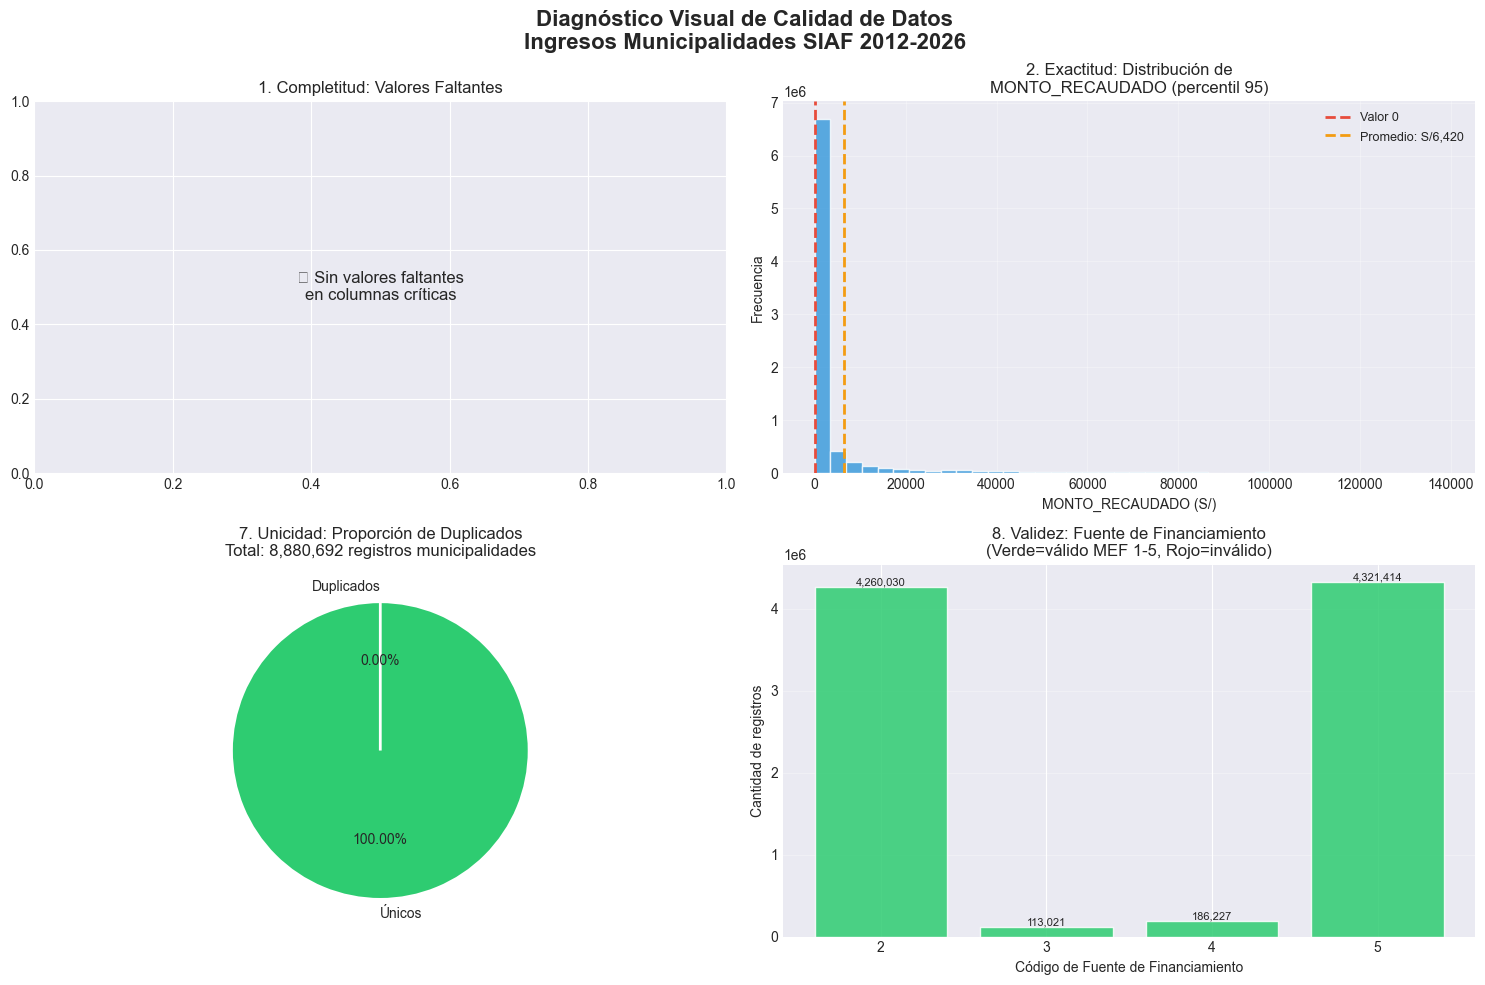

In [22]:
# Visualizaciones de diagnóstico - Ingresos Municipalidades SIAF
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(
    'Diagnóstico Visual de Calidad de Datos\nIngresos Municipalidades SIAF 2012-2026',
    fontsize=16, fontweight='bold'
)

# 1. Completitud: valores faltantes por columna
if len(missing_df) > 0:
    cols_mostrar = missing_df.head(10)
    colores_comp = [
        '#e74c3c' if c in COLUMNAS_CRITICAS else '#f39c12'
        for c in cols_mostrar.index
    ]
    axes[0, 0].barh(
        cols_mostrar.index,
        cols_mostrar['Valores Faltantes'],
        color=colores_comp
    )
    axes[0, 0].set_xlabel('Cantidad de valores faltantes')
    axes[0, 0].set_title('1. Completitud: Valores Faltantes\n'
                         '(Rojo=columna crítica)')
    axes[0, 0].grid(axis='x', alpha=0.3)
else:
    axes[0, 0].text(
        0.5, 0.5,
        '✅ Sin valores faltantes\nen columnas críticas',
        ha='center', va='center', fontsize=12
    )
    axes[0, 0].set_title('1. Completitud: Valores Faltantes')

# 2. Exactitud: distribución de MONTO_RECAUDADO
monto_valido = df_munic[
    (df_munic['MONTO_RECAUDADO'] >= 0) &
    (df_munic['MONTO_RECAUDADO'] <= df_munic['MONTO_RECAUDADO'].quantile(0.95))
]['MONTO_RECAUDADO']

axes[0, 1].hist(monto_valido, bins=40, color='#3498db',
                edgecolor='white', alpha=0.8)
axes[0, 1].axvline(0, color='#e74c3c', linestyle='--',
                   linewidth=2, label='Valor 0')
axes[0, 1].axvline(monto_valido.mean(), color='#f39c12',
                   linestyle='--', linewidth=2,
                   label=f'Promedio: S/{monto_valido.mean():,.0f}')
axes[0, 1].set_xlabel('MONTO_RECAUDADO (S/)')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].set_title('2. Exactitud: Distribución de\nMONTO_RECAUDADO (percentil 95)')
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(alpha=0.3)

# 3. Unicidad: proporción de duplicados vs únicos
duplicados_summary = pd.Series({
    'Únicos':      len(df_munic) - len(duplicados_exactos),
    'Duplicados':  len(duplicados_exactos)
})
colores_unic = ['#2ecc71', '#e74c3c']
axes[1, 0].pie(
    duplicados_summary,
    labels=duplicados_summary.index,
    autopct='%1.2f%%',
    colors=colores_unic,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1, 0].set_title(
    f'7. Unicidad: Proporción de Duplicados\n'
    f'Total: {len(df_munic):,} registros municipalidades'
)

# 4. Validez: distribución por FUENTE_FINANCIAMIENTO
fuente_counts = df_munic['FUENTE_FINANCIAMIENTO'].value_counts().sort_index()
colores_fuente = [
    '#2ecc71' if f in FUENTES_VALIDAS else '#e74c3c'
    for f in fuente_counts.index
]
axes[1, 1].bar(
    fuente_counts.index.astype(str),
    fuente_counts.values,
    color=colores_fuente,
    alpha=0.85,
    edgecolor='white'
)
axes[1, 1].set_xlabel('Código de Fuente de Financiamiento')
axes[1, 1].set_ylabel('Cantidad de registros')
axes[1, 1].set_title('8. Validez: Fuente de Financiamiento\n'
                     '(Verde=válido MEF 1-5, Rojo=inválido)')
axes[1, 1].grid(axis='y', alpha=0.3)
for i, (cod, val) in enumerate(zip(fuente_counts.index, fuente_counts.values)):
    axes[1, 1].text(i, val + 100, f'{val:,}',
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

### Interpretación de las Visualizaciones

**Gráfico 1 — Completitud:**
- Las barras en rojo indican columnas críticas para el análisis presupuestal
- Si `MONTO_PIA`, `MONTO_PIM` o `MONTO_RECAUDADO` tienen faltantes,
  el cálculo de la tasa de ejecución quedará incompleto

**Gráfico 2 — Exactitud:**
- La distribución de `MONTO_RECAUDADO` muestra la concentración de montos
  en rangos bajos, típico de municipalidades pequeñas
- Los valores negativos son imposibles y deben corregirse antes de Silver

**Gráfico 3 — Unicidad:**
- Si hay duplicados exactos, los totales de recaudación quedarían inflados
- Un mismo municipio con el mismo rubro registrado dos veces duplicaría
  artificialmente su ejecución presupuestal

**Gráfico 4 — Validez:**
- Las barras verdes corresponden a fuentes de financiamiento válidas
  según el catálogo del MEF (1 al 5)
- Las barras rojas (si existen) indican códigos inválidos que romperían
  el JOIN con las tablas de dimensiones en Gold

---

# SOLUCIÓN NIVEL SIMPLE

## Objetivo
Aplicar técnicas básicas de limpieza sobre el dataset de Ingresos
Municipalidades SIAF 2012-2026:
- Filtrar solo registros de Gobiernos Locales (NIVEL_GOBIERNO = 'M')
- Eliminar registros con valores nulos en columnas críticas
- Eliminar duplicados exactos
- Filtrar montos obviamente incorrectos (negativos)
- Construir UBIGEO básico para el JOIN con SISMEPRE y RENAMU

### Limitaciones de este enfoque:
- Pérdida de registros que podrían recuperarse con imputación
- No trata inconsistencias entre campos relacionados
- No detecta outliers estadísticos en los montos

In [23]:
# Crear copia para solución simple - Ingresos Municipalidades SIAF
df_simple = df.copy()

print(f"{'=' * 60}")
print(f"   SOLUCIÓN SIMPLE — LIMPIEZA DE INGRESOS MUNICIPALIDADES")
print(f"{'=' * 60}")
print(f"\nRegistros iniciales (dataset completo): {len(df_simple):,}")
print(f"\nPASOS DE LIMPIEZA:\n")

# Paso 1: Filtrar solo Municipalidades (NIVEL_GOBIERNO = 'M')
antes_filtro = len(df_simple)
df_simple    = df_simple[df_simple['NIVEL_GOBIERNO'] == 'M'].copy()
print(f"1. Filtrado solo municipalidades (NIVEL_GOBIERNO='M'): "
      f"{antes_filtro - len(df_simple):,} registros eliminados "
      f"→ quedan {len(df_simple):,}")

# Paso 2: Eliminar filas con nulos en columnas críticas
antes_nulos = len(df_simple)
df_simple   = df_simple.dropna(subset=COLUMNAS_CRITICAS)
print(f"2. Eliminación de nulos en columnas críticas         : "
      f"{antes_nulos - len(df_simple):,} registros eliminados "
      f"→ quedan {len(df_simple):,}")

# Paso 3: Eliminar duplicados exactos
cols_dup   = [c for c in df_simple.columns if c != 'ARCHIVO_ORIGEN']
antes_dup  = len(df_simple)
df_simple  = df_simple.drop_duplicates(subset=cols_dup, keep='first')
print(f"3. Eliminación de duplicados exactos                 : "
      f"{antes_dup - len(df_simple):,} registros eliminados "
      f"→ quedan {len(df_simple):,}")

# Paso 4: Filtrar montos negativos (imposibles en presupuesto)
antes_neg = len(df_simple)
df_simple = df_simple[
    (df_simple['MONTO_PIA']       >= 0) &
    (df_simple['MONTO_PIM']       >= 0) &
    (df_simple['MONTO_RECAUDADO'] >= 0)
]
print(f"4. Eliminación de montos negativos                   : "
      f"{antes_neg - len(df_simple):,} registros eliminados "
      f"→ quedan {len(df_simple):,}")

# Paso 5: Convertir tipos de dato correctos en montos
df_simple['MONTO_PIA']       = pd.to_numeric(df_simple['MONTO_PIA'],       errors='coerce')
df_simple['MONTO_PIM']       = pd.to_numeric(df_simple['MONTO_PIM'],       errors='coerce')
df_simple['MONTO_RECAUDADO'] = pd.to_numeric(df_simple['MONTO_RECAUDADO'], errors='coerce')
print(f"5. Corrección de tipos de dato en montos             : Aplicada")

# Paso 6: Construir UBIGEO básico (necesario para JOIN con SISMEPRE y RENAMU)
df_simple['UBIGEO'] = (
    df_simple['DEPARTAMENTO_EJECUTORA'].astype(str).str.zfill(2) +
    df_simple['PROVINCIA_EJECUTORA'].astype(str).str.zfill(2)   +
    df_simple['DISTRITO_EJECUTORA'].astype(str).str.zfill(2)
)
print(f"6. Construcción de UBIGEO (6 dígitos)                : Aplicada")

# Paso 7: Estandarizar nombres de departamento (mayúsculas)
df_simple['DEPARTAMENTO_EJECUTORA_NOMBRE'] = (
    df_simple['DEPARTAMENTO_EJECUTORA_NOMBRE']
    .str.upper().str.strip()
)
print(f"7. Estandarización de nombres de departamento        : Aplicada")

# Resumen de pérdida
perdida = len(df[df['NIVEL_GOBIERNO'] == 'M']) - len(df_simple)
print(f"\n{'─' * 60}")
print(f" Registros municipalidades iniciales : "
      f"{len(df[df['NIVEL_GOBIERNO'] == 'M']):,}")
print(f" Registros finales (Silver simple)   : {len(df_simple):,}")
print(f" Pérdida total                       : {perdida:,} registros "
      f"({perdida/len(df[df['NIVEL_GOBIERNO']=='M'])*100:.1f}%)")

   SOLUCIÓN SIMPLE — LIMPIEZA DE INGRESOS MUNICIPALIDADES

Registros iniciales (dataset completo): 10,777,068

PASOS DE LIMPIEZA:

1. Filtrado solo municipalidades (NIVEL_GOBIERNO='M'): 1,896,376 registros eliminados → quedan 8,880,692
2. Eliminación de nulos en columnas críticas         : 0 registros eliminados → quedan 8,880,692
3. Eliminación de duplicados exactos                 : 0 registros eliminados → quedan 8,880,692
4. Eliminación de montos negativos                   : 76,212 registros eliminados → quedan 8,804,480
5. Corrección de tipos de dato en montos             : Aplicada
6. Construcción de UBIGEO (6 dígitos)                : Aplicada
7. Estandarización de nombres de departamento        : Aplicada

────────────────────────────────────────────────────────────
 Registros municipalidades iniciales : 8,880,692
 Registros finales (Silver simple)   : 8,804,480
 Pérdida total                       : 76,212 registros (0.9%)


In [25]:
# Verificación post-limpieza
print(f"{'=' * 60}")
print(f"   VERIFICACIÓN POST-LIMPIEZA (SOLUCIÓN SIMPLE)")
print(f"{'=' * 60}")

print(f"\n Valores nulos en columnas críticas : "
      f"{df_simple[COLUMNAS_CRITICAS].isnull().sum().sum()}")
print(f" Duplicados exactos                 : "
      f"{df_simple.duplicated(subset=cols_dup).sum()}")
print(f" MONTO_PIA negativos                : "
      f"{len(df_simple[df_simple['MONTO_PIA'] < 0])}")
print(f" MONTO_PIM negativos                : "
      f"{len(df_simple[df_simple['MONTO_PIM'] < 0])}")
print(f" MONTO_RECAUDADO negativos          : "
      f"{len(df_simple[df_simple['MONTO_RECAUDADO'] < 0])}")
print(f" UBIGEO construido (6 dígitos)      : "
      f"{(df_simple['UBIGEO'].str.len() == 6).sum():,} registros")
print(f"\n Cobertura temporal: "
      f"{df_simple['ANO_DOC'].min()} - {df_simple['ANO_DOC'].max()}")
print(f"  Municipalidades distintas: "
      f"{df_simple['SEC_EJEC'].nunique():,}")

   VERIFICACIÓN POST-LIMPIEZA (SOLUCIÓN SIMPLE)

 Valores nulos en columnas críticas : 0
 Duplicados exactos                 : 0
 MONTO_PIA negativos                : 0
 MONTO_PIM negativos                : 0
 MONTO_RECAUDADO negativos          : 0
 UBIGEO construido (6 dígitos)      : 8,804,480 registros

 Cobertura temporal: 2012 - 2026
  Municipalidades distintas: 1,964


In [28]:
# Convertir columnas con tipos mixtos a string para compatibilidad con Parquet
columnas_a_string = [
    'DEPARTAMENTO_EJECUTORA',
    'PROVINCIA_EJECUTORA', 
    'DISTRITO_EJECUTORA',
    'SECTOR',
    'PLIEGO',
    'EJECUTORA',
    'RUBRO',
    'GENERICA',
    'SUBGENERICA',
    'SUBGENERICA_DET',
    'ESPECIFICA',
    'ESPECIFICA_DET',
    'FUENTE_FINANCIAMIENTO',
    'TIPO_RECURSO'
]

for col in columnas_a_string:
    if col in df_simple.columns:
        df_simple[col] = df_simple[col].astype(str)

# Guardar Silver simple
df_simple.to_parquet('ingresos_silver_simple.parquet', index=False)

print(f"✅ Archivo guardado: ingresos_silver_simple.parquet")
print(f"   Registros: {len(df_simple):,}")
print(f"   Columnas : {len(df_simple.columns)}")

✅ Archivo guardado: ingresos_silver_simple.parquet
   Registros: 8,804,480
   Columnas : 38


### Conclusiones de la Solución Simple

**Ventajas:**
- Fácil de implementar y auditar paso a paso
- Elimina errores evidentes (negativos, nulos críticos, duplicados)
- Produce un archivo limpio listo para exploración inicial
- Garantiza el UBIGEO necesario para el JOIN final en Silver

**Desventajas:**
- Pérdida de registros que podrían recuperarse con imputación
- No trata outliers estadísticos en MONTO_PIM ni MONTO_RECAUDADO
- No verifica inconsistencias entre RUBRO y FUENTE_FINANCIAMIENTO
- No calcula la TASA_EJECUCION ni otros KPIs — eso va en Gold